In [25]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# Initialize LLM (Groq)
from langchain_ollama import ChatOllama

llm = ChatOllama(
    model="llama3.1:8b",
    base_url="http://localhost:11434",
    temperature=0
)


# Define State
class State(TypedDict):
    # Messages are appended instead of overwritten
    messages: Annotated[list, add_messages]


# Node Function
def chatbot(state: State):
    return {
        "messages": [llm.invoke(state["messages"])]
    }


# Create Graph
graph_builder = StateGraph(State)

# Add Node
graph_builder.add_node("llmchatbot", chatbot)

# Add Edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# Compile Graph
graph = graph_builder.compile()

# Visualize Graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

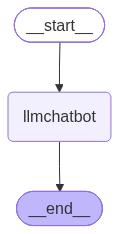

In [28]:
## Visualize the graph
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [26]:
response = graph.invoke(
    {
        "messages": [
            ("user", "What is LangGraph?")
        ]
    }
)

print(response["messages"][-1].content)

LangGraph is a graph-based language model that represents languages as graphs, where each node in the graph corresponds to a word or a subword, and edges represent relationships between these nodes. This approach allows for more nuanced and context-dependent modeling of linguistic structures.

The key features of LangGraph include:

1.  **Graph-Based Representation**: LangGraph uses a graph-based representation to model languages. Each node in the graph represents a word or a subword, while edges capture the relationships between these nodes.
2.  **Contextualized Embeddings**: The model generates contextualized embeddings for each node in the graph, which are learned during training and capture the nuances of language use in context.
3.  **Multi-Task Learning**: LangGraph is designed to perform multiple tasks simultaneously, such as language modeling, machine translation, and text classification.

LangGraph has been shown to outperform other state-of-the-art models on several benchmark

In [33]:
response = graph.invoke({'messages':'hi'})
response['messages']

[HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='64474259-5f2a-432e-a0c3-8d5eb595fa95'),
 AIMessage(content="How's it going? Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-07-18T16:08:41.771939732Z', 'done': True, 'done_reason': 'stop', 'total_duration': 700860418, 'load_duration': 107396363, 'prompt_eval_count': 11, 'prompt_eval_duration': 180393987, 'eval_count': 21, 'eval_duration': 394798602, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019f75fc-ab68-7ff1-9666-9a205feaf927-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 11, 'output_tokens': 21, 'total_tokens': 32})]

In [ ]:

# This code is required when the llm not working and we need to take the help from graq llm
import os
from dotenv import load_dotenv
load_dotenv()

False

In [30]:
for event in graph.stream({"messages":"Hi How are you?"}):
    for value in event.values():
        print(value["messages"][-1].content)

I'm just a computer program, so I don't have feelings like humans do. But thank you for asking! How can I assist you today?


## Chatbot With Tool

In [6]:


import asyncio
from langchain_mcp_adapters.client import MultiServerMCPClient


def get_mcp_tools():

    client = MultiServerMCPClient(
        {
            "Kepware": {
                "url": "http://127.0.0.1:8000/mcp",
                "transport": "streamable_http",
            }
        }
    )

    tools = client.get_tools()

    return tools

C:\Users\Rohit\AppData\Local\Temp\ipykernel_6604\261945258.py:55: RuntimeWarning: coroutine 'MultiServerMCPClient.get_tools' was never awaited
  tools = [tool, human_assistance]


PydanticInvalidForJsonSchema: Failed to generate JSON schema for 'tool': Cannot generate a JsonSchema for core_schema.IsInstanceSchema (<class 'langchain_core.runnables.base.Runnable'>)

For further information visit https://errors.pydantic.dev/2.13/u/invalid-for-json-schema

Tool argument schemas must be JSON-serializable. If your schema includes custom Python classes, consider:
  1. Converting them to Pydantic models with JSON-compatible fields
  2. Using primitive types (str, int, float, bool, list, dict) instead
  3. Passing the data as serialized JSON strings



For further information visit https://errors.pydantic.dev/2.13/u/invalid-for-json-schema

In [4]:
from NewClient_MCP import get_mcp_tools

ImportError: cannot import name 'get_mcp_tools' from 'NewClient_MCP' (c:\RAG_POC\LangGraph\NewClient_MCP.py)

In [21]:
import asyncio
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode, tools_condition

from langchain_ollama import ChatOllama
from langchain_mcp_adapters.client import MultiServerMCPClient
import nest_asyncio
nest_asyncio.apply()


# ----------------------------
# Initialize LLM
# ----------------------------
llm = ChatOllama(
    model="llama3.1:8b",
    base_url="http://localhost:11434",
    temperature=0,
)


# ----------------------------
# State
# ----------------------------
class State(TypedDict):
    messages: Annotated[list, add_messages]


async def main():

    # ----------------------------
    # Connect to MCP Server
    # ----------------------------
    client = MultiServerMCPClient(
        {
            "Kepware": {
                "url": "http://127.0.0.1:8000/mcp",
                "transport": "streamable_http",
            }
        }
    )

    # ----------------------------
    # Load MCP Tools
    # ----------------------------
    tools = await client.get_tools()

    print("\nAvailable Tools:")
    for tool in tools:
        print("-", tool.name)

    # ----------------------------
    # Bind tools to LLM
    # ----------------------------
    llm_with_tools = llm.bind_tools(tools)

    # ----------------------------
    # LLM Node
    # ----------------------------
    def chatbot(state: State):
        response = llm_with_tools.invoke(state["messages"])
        return {"messages": [response]}

    # ----------------------------
    # Build LangGraph
    # ----------------------------
    graph_builder = StateGraph(State)

    graph_builder.add_node("chatbot", chatbot)
    graph_builder.add_node("tools", ToolNode(tools))

    graph_builder.add_edge(START, "chatbot")

    graph_builder.add_conditional_edges(
        "chatbot",
        tools_condition,
    )

    graph_builder.add_edge("tools", "chatbot")

    graph_builder.add_edge("chatbot", END)

    graph = graph_builder.compile()

    # ----------------------------
    # Invoke Graph
    # ----------------------------
    response = await graph.ainvoke(
        {
            "messages": [
                (
                    "user",
                    "Please make the changes for channel5, Floating point values from Replace with Zero to Unmodified."
                )
            ]
        }
    )

    print("\nAssistant Response:\n")
    print(response["messages"][-1].content)


if __name__ == "__main__":
    asyncio.run(main())

AsyncLibraryNotFoundError: unknown async library, or not in async context

In [22]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

# Initialize LLM (Groq)
from langchain_ollama import ChatOllama

from langchain.chat_models import init_chat_model

from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode, tools_condition

llm = ChatOllama(
    model="llama3.1:8b",
    base_url="http://localhost:11434",
    temperature=0
)


# Define State
class State(TypedDict):
    # Messages are appended instead of overwritten
    messages: Annotated[list, add_messages]

# Node Function
def kepware_chatbot(state: State):
    return {
        "messages": [llm.invoke(state["messages"])]
    }

# Create Graph
graph_builder = StateGraph(State)

# Add Node
graph_builder.add_node("llmchatbot", kepware_chatbot)
graph_builder.add_node("tools", ToolNode(tools))

# Add Edges
graph_builder.add_edge(START, "llmchatbot")

# Compile Graph
graph_builder.add_conditional_edges("chatbot", tools_condition)
graph_builder.add_edge("llmchatbot", END)
graph = graph_builder.compile()
# Visualize Graph
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass




ValueError: Found edge starting at unknown node 'chatbot'